# Decision Tree Classification — Heart Disease Dataset
**Objective:** Apply Decision Tree Classification, analyse performance, and interpret results.

---
## Task 1 — Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')

# Load dataset
df = pd.read_excel('heart_disease.xlsx', sheet_name='Heart_disease')
print('Shape:', df.shape)
df.head()

Shape: (908, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [2]:
print('Columns:', df.columns.tolist())
print('\nDtypes:')
print(df.dtypes)
print('\nTarget distribution (num):')
print(df['num'].value_counts())

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']

Dtypes:
age           int64
sex             str
cp              str
trestbps      int64
chol          int64
fbs          object
restecg         str
thalch        int64
exang        object
oldpeak     float64
slope           str
thal            str
num           int64
dtype: object

Target distribution (num):
num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64


---
## Task 2 — Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
count,908.000000,908,908,908.000000,908.000000,908,908,908.000000,908,846.000000,908,908,908.000000
unique,NaN,2,4,NaN,NaN,4,3,NaN,4,NaN,3,3,NaN
top,NaN,Male,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,normal,NaN
freq,NaN,718,495,NaN,NaN,680,542,NaN,516,NaN,453,386,NaN
mean,53.791850,NaN,NaN,133.430617,201.484581,NaN,NaN,135.957048,NaN,0.891253,NaN,NaN,1.008811
std,9.158031,NaN,NaN,20.401608,112.097949,NaN,NaN,26.804929,NaN,1.093875,NaN,NaN,1.144436
min,29.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,NaN,0.000000
25%,47.750000,NaN,NaN,120.000000,176.750000,NaN,NaN,118.000000,NaN,0.000000,NaN,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,224.000000,NaN,NaN,138.000000,NaN,0.500000,NaN,NaN,1.000000
75%,60.000000,NaN,NaN,144.000000,270.000000,NaN,NaN,156.000000,NaN,1.500000,NaN,NaN,2.000000


In [4]:
# Missing values
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0])

Missing Values:
oldpeak    62
dtype: int64


Binarized Target Distribution:
target
1    509
0    399
Name: count, dtype: int64


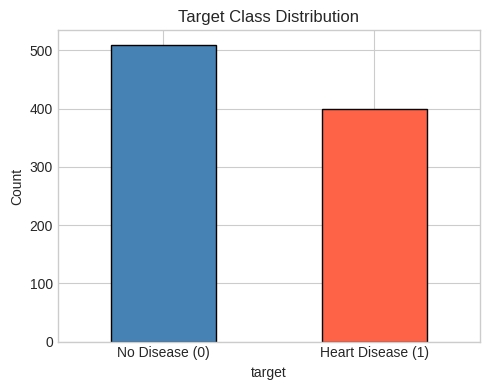

In [5]:
# Binarize target: 0 = no disease, 1 = heart disease (any stage)
df['target'] = (df['num'] > 0).astype(int)
print('Binarized Target Distribution:')
print(df['target'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'], rotation=0)
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

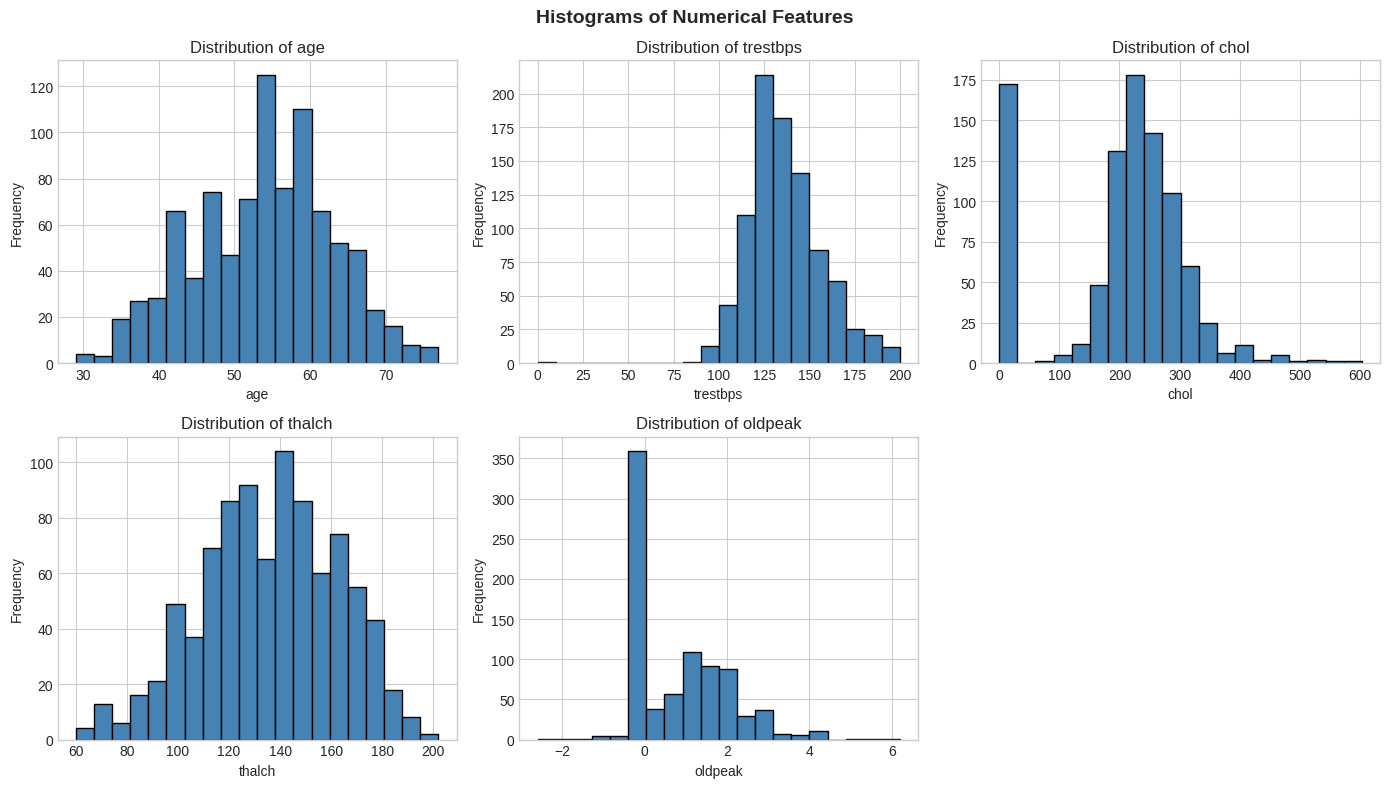

In [6]:
# Histograms for numerical features
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].axis('off')
plt.suptitle('Histograms of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

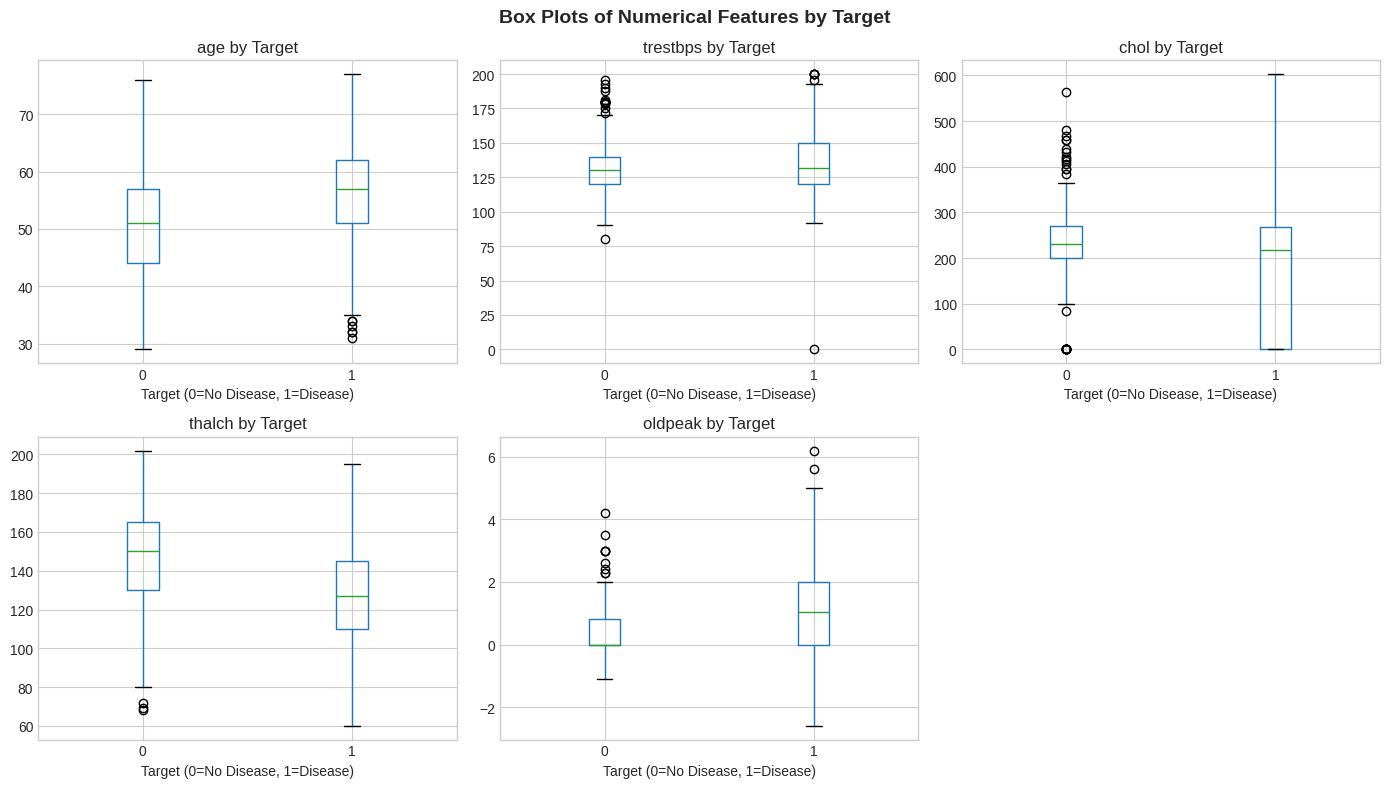

In [7]:
# Box plots for numerical features by target
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(f'{col} by Target')
    axes[i].set_xlabel('Target (0=No Disease, 1=Disease)')
axes[-1].axis('off')
plt.suptitle('Box Plots of Numerical Features by Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

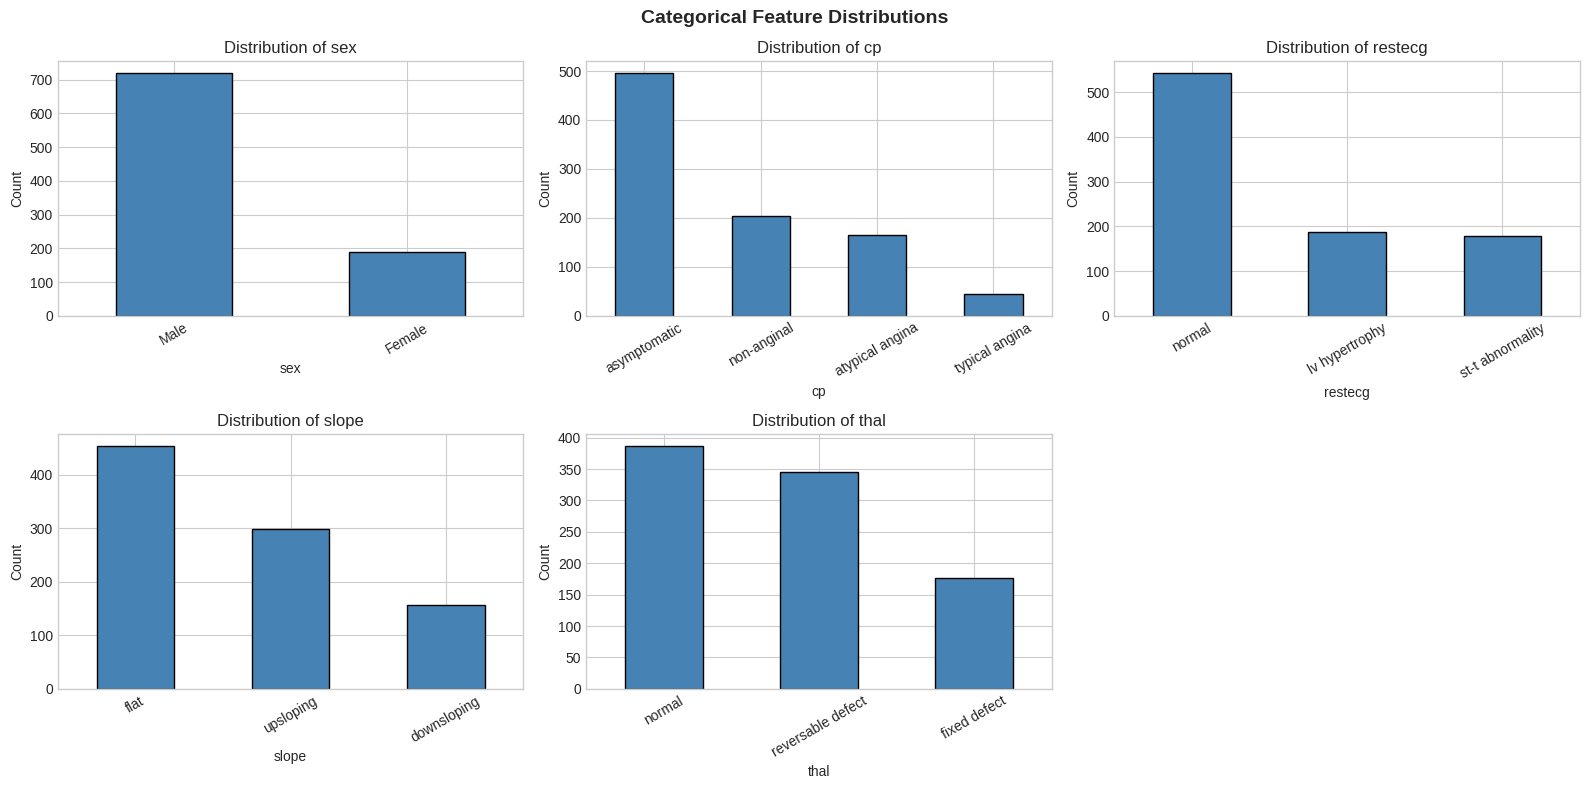

In [8]:
# Categorical feature distribution
cat_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

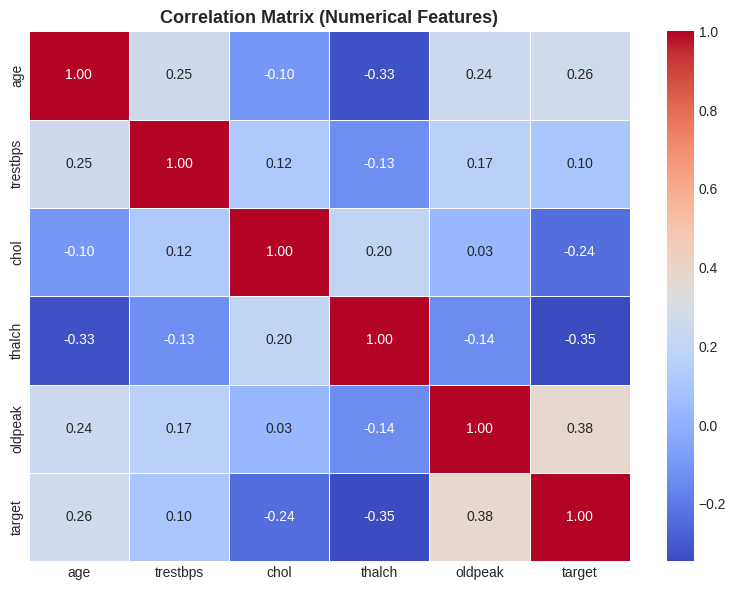

In [9]:
# Correlation matrix (after encoding)
df_corr = df[num_cols + ['target']].copy()
corr = df_corr.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix (Numerical Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 3 — Feature Engineering

In [10]:
df_model = df.copy()

# Handle missing values in oldpeak (fill with median)
df_model['oldpeak'].fillna(df_model['oldpeak'].median(), inplace=True)
print('Missing after imputation:', df_model.isnull().sum().sum())

# Convert boolean-like columns (handle mixed types and typos like 'TURE')
def to_binary(val):
    if isinstance(val, bool): return int(val)
    s = str(val).strip().upper()
    return 1 if s in ('TRUE', 'TURE', '1') else 0
df_model['fbs'] = df_model['fbs'].apply(to_binary)
df_model['exang'] = df_model['exang'].apply(to_binary)

# Label encode sex (binary)
df_model['sex'] = df_model['sex'].map({'Male': 1, 'Female': 0})

# One-hot encode multi-class categorical columns
df_model = pd.get_dummies(df_model, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=False)

# Drop original num column (already have 'target')
df_model.drop(columns=['num'], inplace=True)

print('Shape after encoding:', df_model.shape)
print('Columns:', df_model.columns.tolist())

Missing after imputation: 62
Shape after encoding: (908, 22)
Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'target', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect']


In [11]:
# Define features and target
X = df_model.drop(columns=['target'])
y = df_model['target']
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (908, 21)
y shape: (908,)


---
## Task 4 — Decision Tree Classification (80-20 Split)

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 726 | Test size: 182


In [13]:
# Base Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)
y_prob_base = dt_base.predict_proba(X_test)[:, 1]

print('=== Base Decision Tree Performance ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_base):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_base):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_base):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob_base):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=['No Disease', 'Heart Disease']))

=== Base Decision Tree Performance ===
Accuracy  : 0.7363
Precision : 0.7700
Recall    : 0.7549
F1-Score  : 0.7624
ROC-AUC   : 0.7337

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.70      0.71      0.70        80
Heart Disease       0.77      0.75      0.76       102

     accuracy                           0.74       182
    macro avg       0.73      0.73      0.73       182
 weighted avg       0.74      0.74      0.74       182



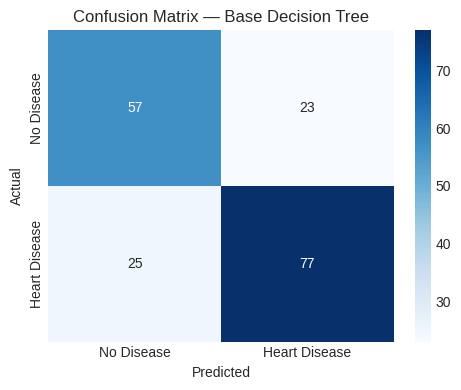

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix — Base Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Task 5 — Hyperparameter Tuning

In [15]:
# GridSearchCV for hyperparameter tuning
param_grid = {
    'criterion'         : ['gini', 'entropy'],
    'max_depth'         : [3, 5, 7, 10, None],
    'min_samples_split' : [2, 5, 10, 20],
    'min_samples_leaf'  : [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print('Best Params :', grid_search.best_params_)
print('Best CV F1  :', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 120 candidates, totalling 600 fits


Best Params : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV F1  : 0.8042


In [16]:
# Evaluate tuned model
dt_tuned = grid_search.best_estimator_
y_pred_tuned = dt_tuned.predict(X_test)
y_prob_tuned = dt_tuned.predict_proba(X_test)[:, 1]

print('=== Tuned Decision Tree Performance ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_tuned):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob_tuned):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Heart Disease']))

=== Tuned Decision Tree Performance ===
Accuracy  : 0.7143
Precision : 0.7604
Recall    : 0.7157
F1-Score  : 0.7374
ROC-AUC   : 0.8029

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.66      0.71      0.69        80
Heart Disease       0.76      0.72      0.74       102

     accuracy                           0.71       182
    macro avg       0.71      0.71      0.71       182
 weighted avg       0.72      0.71      0.72       182



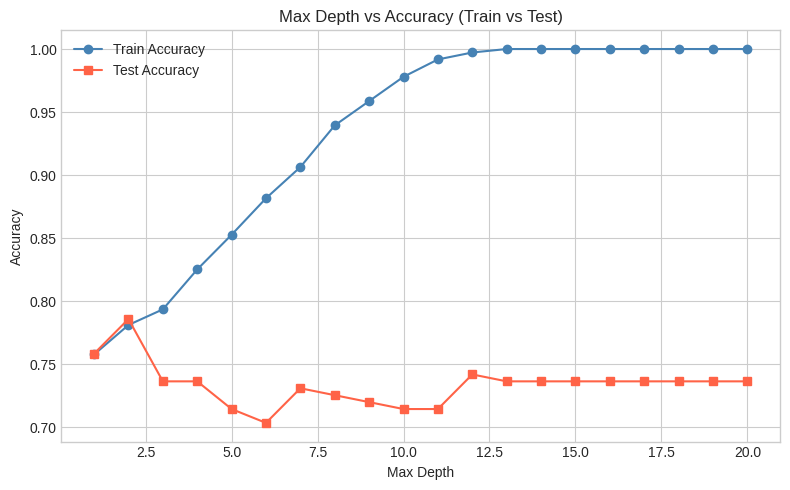

In [17]:
# Max depth vs Accuracy (train & test)
depths = list(range(1, 21))
train_scores, test_scores = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_scores, 's-', label='Test Accuracy', color='tomato')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Max Depth vs Accuracy (Train vs Test)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Task 6 — Model Evaluation & Analysis

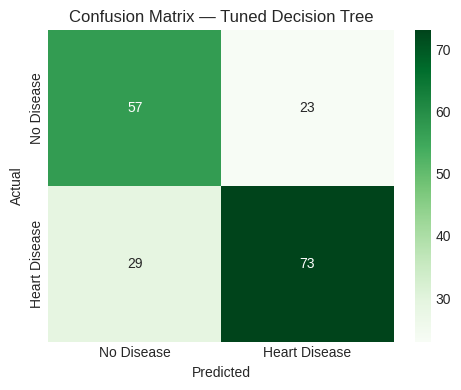

In [18]:
# Confusion Matrix — Tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix — Tuned Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

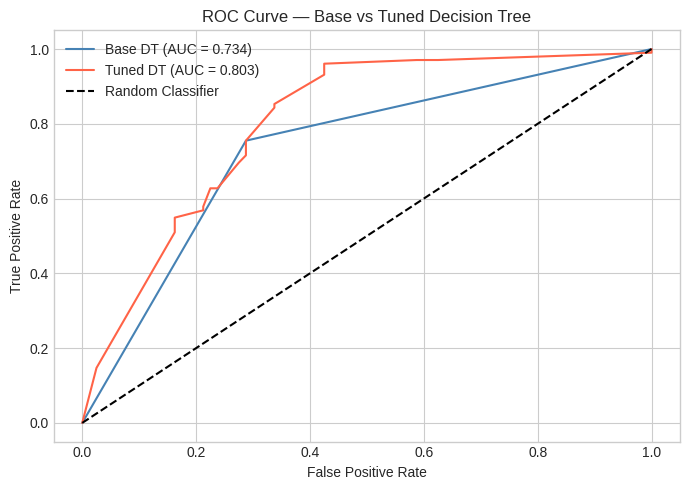

In [19]:
# ROC Curve comparison
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(7, 5))
plt.plot(fpr_base, tpr_base, label=f'Base DT (AUC = {roc_auc_score(y_test, y_prob_base):.3f})', color='steelblue')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned DT (AUC = {roc_auc_score(y_test, y_prob_tuned):.3f})', color='tomato')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Base vs Tuned Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Model Comparison Table
results = pd.DataFrame({
    'Model'    : ['Base Decision Tree', 'Tuned Decision Tree'],
    'Accuracy' : [accuracy_score(y_test, y_pred_base), accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, y_pred_base), precision_score(y_test, y_pred_tuned)],
    'Recall'   : [recall_score(y_test, y_pred_base), recall_score(y_test, y_pred_tuned)],
    'F1-Score' : [f1_score(y_test, y_pred_base), f1_score(y_test, y_pred_tuned)],
    'ROC-AUC'  : [roc_auc_score(y_test, y_prob_base), roc_auc_score(y_test, y_prob_tuned)]
}).round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Base Decision Tree,0.7363,0.7700,0.7549,0.7624,0.7337
1,Tuned Decision Tree,0.7143,0.7604,0.7157,0.7374,0.8029


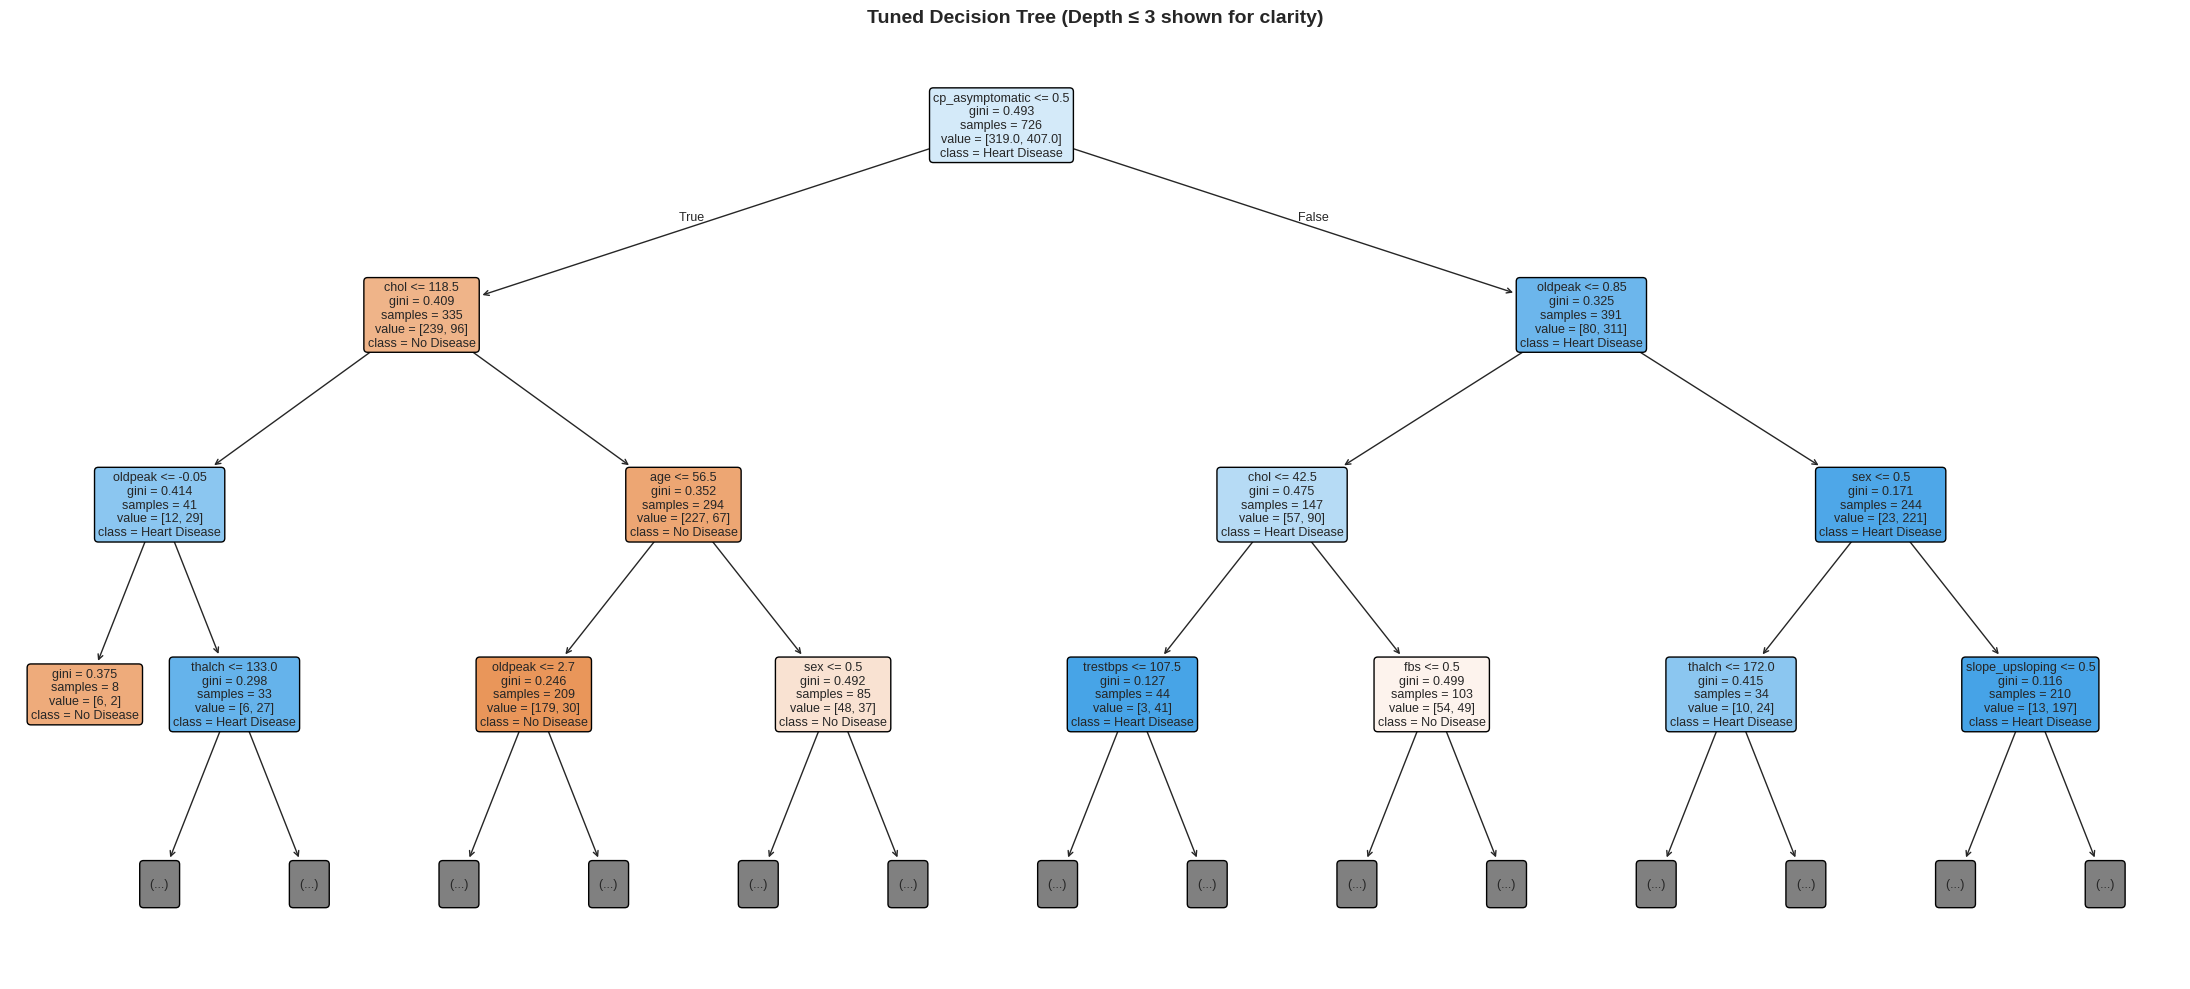

In [21]:
# Decision Tree Visualization
feature_names = X.columns.tolist()
plt.figure(figsize=(22, 10))
plot_tree(
    dt_tuned,
    feature_names=feature_names,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.title('Tuned Decision Tree (Depth ≤ 3 shown for clarity)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

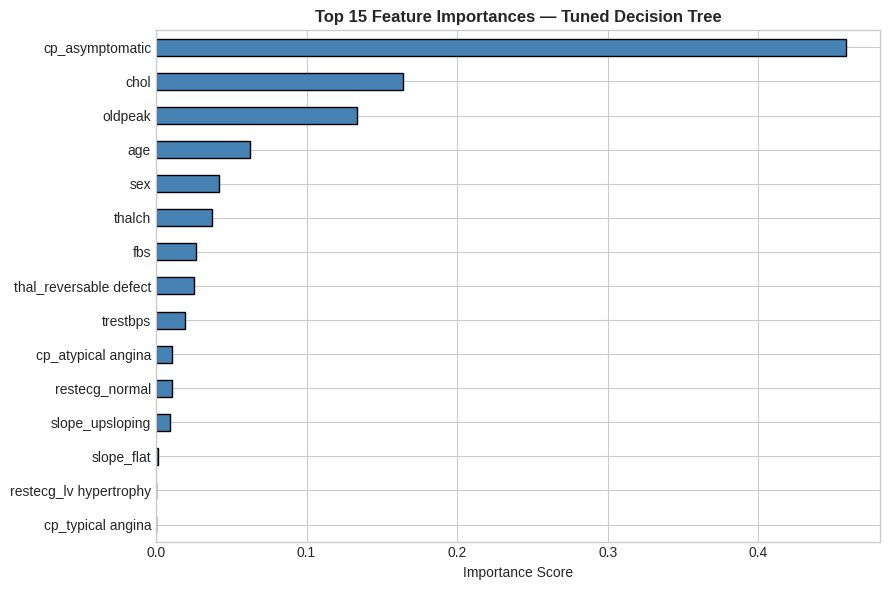

cp_asymptomatic           0.458009
chol                      0.164212
oldpeak                   0.133698
age                       0.062295
sex                       0.041789
thalch                    0.036998
fbs                       0.026309
thal_reversable defect    0.025573
trestbps                  0.019519
cp_atypical angina        0.010873
restecg_normal            0.010459
slope_upsloping           0.009239
slope_flat                0.001027
restecg_lv hypertrophy    0.000000
cp_typical angina         0.000000
dtype: float64


In [22]:
# Feature Importance
importances = pd.Series(dt_tuned.feature_importances_, index=feature_names).sort_values(ascending=False)
top15 = importances.head(15)

plt.figure(figsize=(9, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Tuned Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(top15)

In [23]:
# Decision Rules (text)
rules = export_text(dt_tuned, feature_names=feature_names, max_depth=3)
print('Decision Tree Rules (first 3 levels):')
print(rules)

Decision Tree Rules (first 3 levels):
|--- cp_asymptomatic <= 0.50
|   |--- chol <= 118.50
|   |   |--- oldpeak <= -0.05
|   |   |   |--- class: 0
|   |   |--- oldpeak >  -0.05
|   |   |   |--- thalch <= 133.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- thalch >  133.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- chol >  118.50
|   |   |--- age <= 56.50
|   |   |   |--- oldpeak <= 2.70
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- oldpeak >  2.70
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- age >  56.50
|   |   |   |--- sex <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- sex >  0.50
|   |   |   |   |--- truncated branch of depth 2
|--- cp_asymptomatic >  0.50
|   |--- oldpeak <= 0.85
|   |   |--- chol <= 42.50
|   |   |   |--- trestbps <= 107.50
|   |   |   |   |--- class: 0
|   |   |   |--- trestbps >  107.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- chol >  42.50
| 

---
## Interview Questions

### Q1. What are common hyperparameters of Decision Tree models and how do they affect performance?

| Hyperparameter | Description | Effect |
|---|---|---|
| `max_depth` | Maximum depth of the tree | Shallow → underfitting; Deep → overfitting |
| `min_samples_split` | Min samples required to split a node | Higher value → simpler tree, less overfitting |
| `min_samples_leaf` | Min samples required at a leaf node | Higher value → smoother decision boundary |
| `criterion` | Split quality measure: `gini` or `entropy` | `entropy` can produce slightly different splits; `gini` is faster |
| `max_features` | Number of features considered for each split | Reduces overfitting; acts like feature sampling |
| `max_leaf_nodes` | Maximum number of leaf nodes | Limits tree complexity globally |
| `class_weight` | Weight assigned to each class | Useful for imbalanced datasets |

**Key insight:** `max_depth` and `min_samples_split` are the most impactful. A very deep tree will memorize training data (overfit). Tuning these via cross-validation gives the best generalization.

---

### Q2. What is the difference between Label Encoding and One-Hot Encoding?

| Aspect | Label Encoding | One-Hot Encoding |
|---|---|---|
| **How it works** | Assigns integer to each category (e.g., cat→0, dog→1, bird→2) | Creates a binary column for each category |
| **Output** | Single column with integer values | N new binary columns (or N-1 with `drop_first`) |
| **Implied order** | Yes — model may interpret 2 > 1 > 0 (ordinal) | No — each category is independent |
| **When to use** | Ordinal categories (e.g., Low/Medium/High) or tree-based models | Nominal categories (e.g., color, city name) with linear/distance-based models |
| **Risk** | Misleads linear models by implying false ranking | Can cause high dimensionality (curse) if many categories |
| **Example** | `sex`: Male→1, Female→0 (binary OK) | `cp`: 4 types → 4 binary columns |

**In this project:**  
- `sex` → Label Encoded (binary, no ordering issue)  
- `cp`, `restecg`, `slope`, `thal` → One-Hot Encoded (nominal multi-class, no meaningful order)
- `fbs`, `exang` → Mapped directly to 0/1 (already binary boolean)